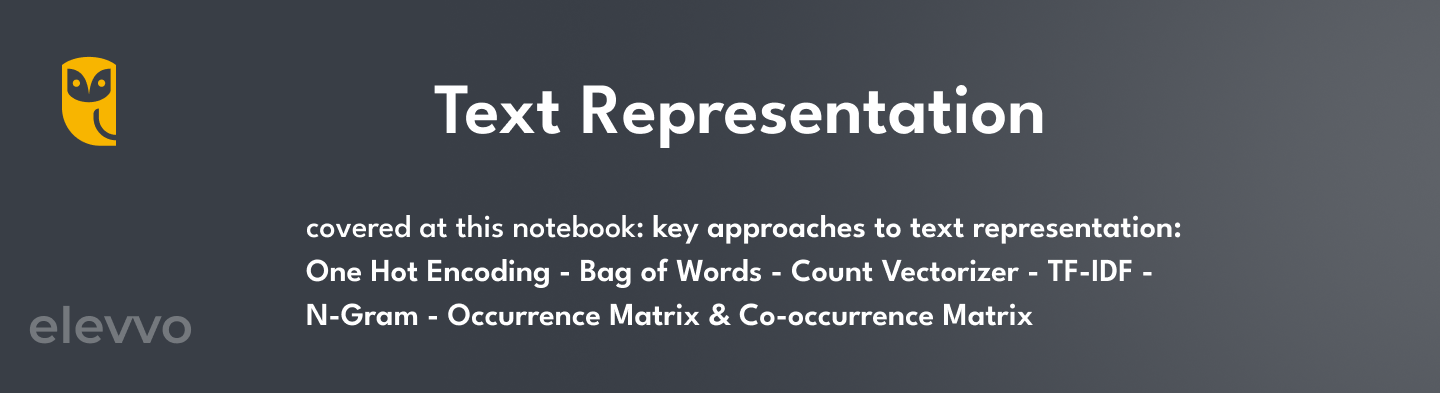

📌 text representation refers to the process of converting `raw text` into a `numerical format` that machine learning models can understand and work with.

📌 Each method offers a different perspective on how to capture the essence of text and pave the way for powerful nlp applications.

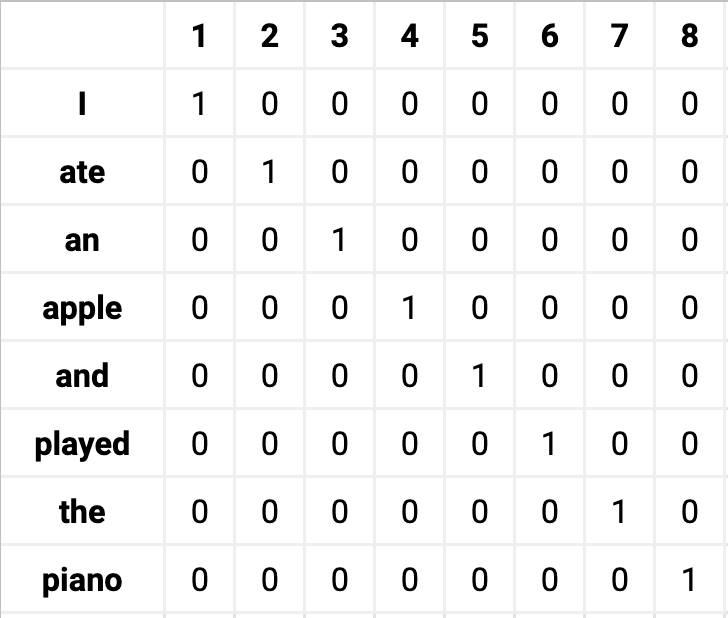

# One-Hot Encoding

📌 creates new columns for each category where 1 means the category is present and 0 means it is not.

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

### Categorical data to be converted to numeric data
colors = (["red", "green", "yellow", "red", "blue"])

### integer mapping using LabelEncoder
label_encoder = LabelEncoder()
integer_encoded = label_encoder.fit_transform(colors)
print(integer_encoded)
integer_encoded = integer_encoded.reshape(len(integer_encoded), 1)

### One hot encoding
onehot_encoder = OneHotEncoder(sparse_output=False)
onehot_encoded = onehot_encoder.fit_transform(integer_encoded)

print(onehot_encoded)

[2 1 3 2 0]
[[0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]]


# Bag of Words

📌 A bag of words is a representation of text that describes the occurrence of words within a document

📌 it ignores the order and structure of words in the document

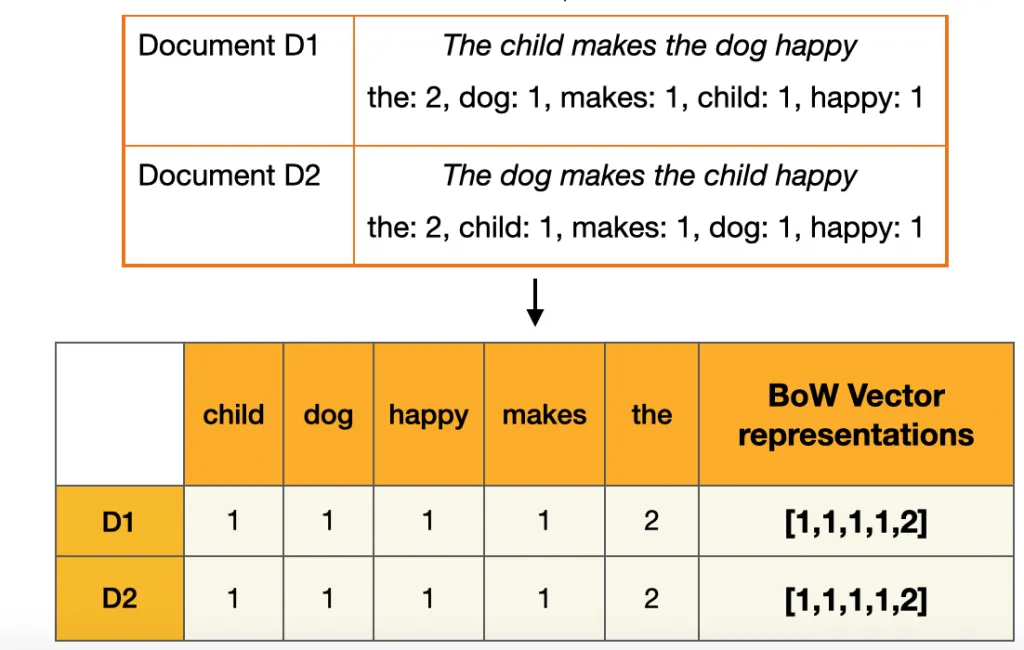

`Source: AIML.com Research`

In [ ]:
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
input_list = ["Joe waited for the train", "The train was late", "Mary and Samantha took the bus", "I looked for Mary and Samantha at the bus station","Mary and Samantha arrived at the bus station early but waited until noon for the bus"]

In [ ]:
from nltk.tokenize import word_tokenize
tokens = []
for i in range(len(input_list)):
    tokens +=(word_tokenize(input_list[i]))

In [ ]:
tokens

['Joe',
 'waited',
 'for',
 'the',
 'train',
 'The',
 'train',
 'was',
 'late',
 'Mary',
 'and',
 'Samantha',
 'took',
 'the',
 'bus',
 'I',
 'looked',
 'for',
 'Mary',
 'and',
 'Samantha',
 'at',
 'the',
 'bus',
 'station',
 'Mary',
 'and',
 'Samantha',
 'arrived',
 'at',
 'the',
 'bus',
 'station',
 'early',
 'but',
 'waited',
 'until',
 'noon',
 'for',
 'the',
 'bus']

In [ ]:
import nltk
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

In [ ]:
clean_tokens = []
for w in tokens:
    if w.lower() not in stop_words:
        clean_tokens.append(w)

In [ ]:
clean_tokens

['Joe',
 'waited',
 'train',
 'train',
 'late',
 'Mary',
 'Samantha',
 'took',
 'bus',
 'looked',
 'Mary',
 'Samantha',
 'bus',
 'station',
 'Mary',
 'Samantha',
 'arrived',
 'bus',
 'station',
 'early',
 'waited',
 'noon',
 'bus']

In [ ]:
import numpy
for sentence in input_list:
    words = word_tokenize(sentence)
    bag_vector = numpy.zeros(len(clean_tokens))
    for w in words:
        for i,word in enumerate(clean_tokens):
            if word == w:
                bag_vector[i] += 1
    print("{0}\n{1}\n".format(sentence,numpy.array(bag_vector)))

Joe waited for the train
[1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]

The train was late
[0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Mary and Samantha took the bus
[0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 0. 1. 0. 0. 0. 0. 1.]

I looked for Mary and Samantha at the bus station
[0. 0. 0. 0. 0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 0. 0. 0. 1.]

Mary and Samantha arrived at the bus station early but waited until noon for the bus
[0. 1. 0. 0. 0. 1. 1. 0. 2. 0. 1. 1. 2. 1. 1. 1. 1. 2. 1. 1. 1. 1. 2.]



# Count Vectorizer

📌 creates a matrix in which `each unique word is represented by a column of the matrix`, and `each text sample from the document is a row in the matrix`. The value of each cell is nothing but the `count of the word` in that particular text sample.

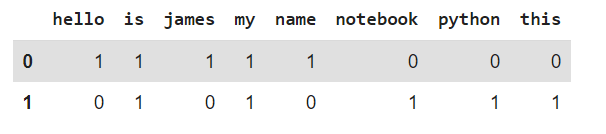

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
# tokenize and build vocab
vectorizer.fit(input_list)

print(vectorizer.vocabulary_)

# encode document
vector = vectorizer.transform(input_list)

# summarize encoded vector
print(vector.shape)
print(vector.toarray())

{'joe': 7, 'waited': 18, 'for': 6, 'the': 14, 'train': 16, 'was': 19, 'late': 8, 'mary': 10, 'and': 0, 'samantha': 12, 'took': 15, 'bus': 3, 'looked': 9, 'at': 2, 'station': 13, 'arrived': 1, 'early': 5, 'but': 4, 'until': 17, 'noon': 11}
(5, 20)
[[0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 1 0 1 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 1]
 [1 0 0 1 0 0 0 0 0 0 1 0 1 0 1 1 0 0 0 0]
 [1 0 1 1 0 0 1 0 0 1 1 0 1 1 1 0 0 0 0 0]
 [1 1 1 2 1 1 1 0 0 0 1 1 1 1 2 0 0 1 1 0]]


# TF-IDF

📌 is a statistical measure used to evaluate the importance of a word in a document relative to a collection of documents (corpus).

📌 Term Frequency (TF): Measures how often a word appears in a document. A higher frequency suggests greater importance. If a term appears frequently in a document, it is likely relevant to the document’s content.

📌 Inverse Document Frequency (IDF): Reduces the weight of common words across multiple documents while increasing the weight of rare words. If a term appears in fewer documents, it is more likely to be meaningful and specific.

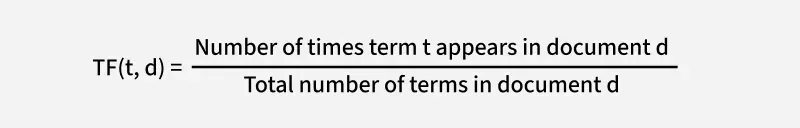

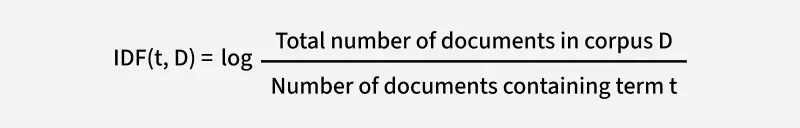

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
vectroizer2 = TfidfVectorizer()

In [ ]:
response = vectroizer2.fit_transform(input_list)

print(response)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 38 stored elements and shape (5, 20)>
  Coords	Values
  (0, 7)	0.5795370067919515
  (0, 18)	0.46756680801802136
  (0, 6)	0.3881226876930511
  (0, 14)	0.27615248891912103
  (0, 16)	0.46756680801802136
  (1, 14)	0.2808823162882302
  (1, 16)	0.47557510189256375
  (1, 19)	0.5894630806320427
  (1, 8)	0.5894630806320427
  (2, 14)	0.2741475469087353
  (2, 10)	0.3853048116536737
  (2, 0)	0.3853048116536737
  (2, 12)	0.3853048116536737
  (2, 15)	0.575329410850889
  (2, 3)	0.3853048116536737
  (3, 6)	0.306593048187538
  (3, 14)	0.21814347892295216
  (3, 10)	0.306593048187538
  (3, 0)	0.306593048187538
  (3, 12)	0.306593048187538
  (3, 3)	0.306593048187538
  (3, 9)	0.4577985855605202
  (3, 2)	0.3693490162959343
  (3, 13)	0.3693490162959343
  (4, 18)	0.23843887678921322
  (4, 6)	0.1979258068001585
  (4, 14)	0.28165168335851165
  (4, 10)	0.1979258068001585
  (4, 0)	0.1979258068001585
  (4, 12)	0.1979258068001585
  (4, 3)	0.39585161360031

# N-Gram

📌 N-gram can be defined as the contiguous sequence of n items from a given sample of text or speech. The items can be letters, words, or base pairs according to the application. The N-grams typically are collected from a text or speech corpus (A long text dataset).

📌 For instance, N-grams can be unigrams like (“This”, “article”, “is”, “on”, “NLP”) or bigrams (“This article”, “article is”, “is on”, “on NLP”), or trigram and so on

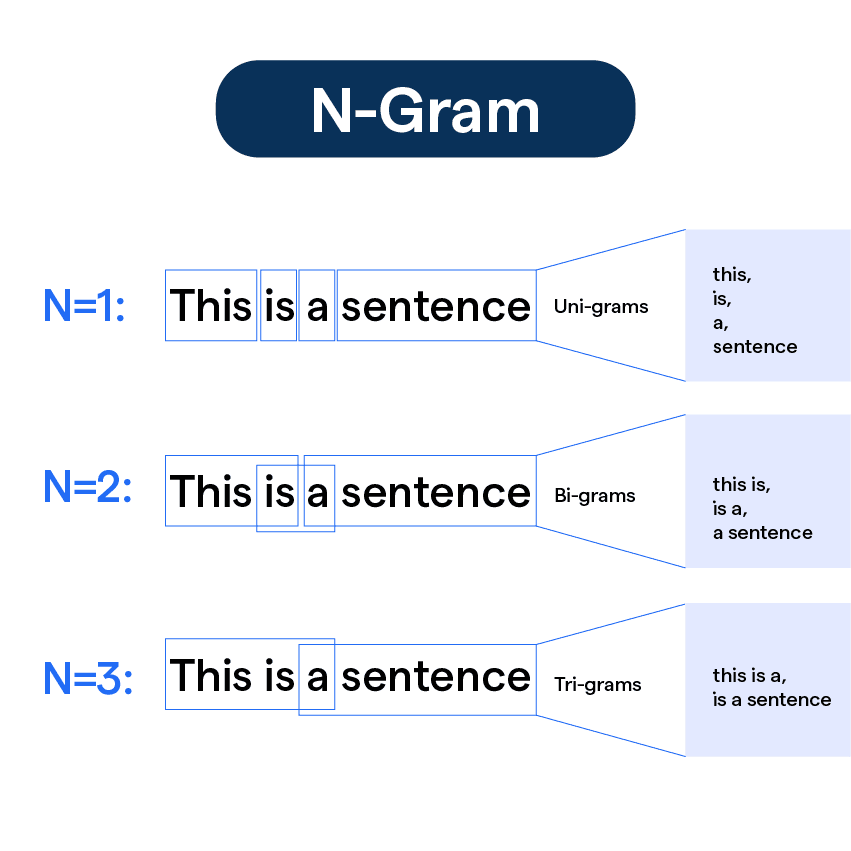

In [ ]:
import re
from nltk.util import ngrams

output = list(ngrams(tokens, 5))

In [ ]:
output

[('Joe', 'waited', 'for', 'the', 'train'),
 ('waited', 'for', 'the', 'train', 'The'),
 ('for', 'the', 'train', 'The', 'train'),
 ('the', 'train', 'The', 'train', 'was'),
 ('train', 'The', 'train', 'was', 'late'),
 ('The', 'train', 'was', 'late', 'Mary'),
 ('train', 'was', 'late', 'Mary', 'and'),
 ('was', 'late', 'Mary', 'and', 'Samantha'),
 ('late', 'Mary', 'and', 'Samantha', 'took'),
 ('Mary', 'and', 'Samantha', 'took', 'the'),
 ('and', 'Samantha', 'took', 'the', 'bus'),
 ('Samantha', 'took', 'the', 'bus', 'I'),
 ('took', 'the', 'bus', 'I', 'looked'),
 ('the', 'bus', 'I', 'looked', 'for'),
 ('bus', 'I', 'looked', 'for', 'Mary'),
 ('I', 'looked', 'for', 'Mary', 'and'),
 ('looked', 'for', 'Mary', 'and', 'Samantha'),
 ('for', 'Mary', 'and', 'Samantha', 'at'),
 ('Mary', 'and', 'Samantha', 'at', 'the'),
 ('and', 'Samantha', 'at', 'the', 'bus'),
 ('Samantha', 'at', 'the', 'bus', 'station'),
 ('at', 'the', 'bus', 'station', 'Mary'),
 ('the', 'bus', 'station', 'Mary', 'and'),
 ('bus', 'statio

# Occurrence Matrix & Co-occurrence Matrix

📌 Occurrence matrix: A matrix showing `how often each item` (e.g., word or feature) `appears in each document` or context.

📌 Co-occurrence matrix: A matrix showing `how often pairs of items appear together within a defined context` (e.g., window, document).

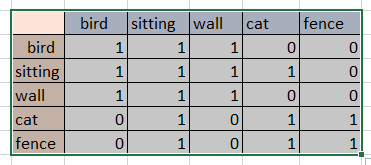

*Image shows an example of co-occurrence matrix*

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Define the input text
text = ["this is a sample text to demonstrate occurrence and co-occurrence matrix"]

# Create a CountVectorizer object
vectorizer = CountVectorizer()

# Fit and transform the input text using the CountVectorizer
count_matrix = vectorizer.fit_transform(text)

# Print the occurrence matrix
print("Occurrence Matrix:")
print(count_matrix.toarray())
print()

# Define the window size for co-occurrence
window_size = 2

# Create a CountVectorizer object for co-occurrence
cooc_vectorizer = CountVectorizer(analyzer='word', ngram_range=(2,2))

# Fit and transform the input text using the co-occurrence CountVectorizer
cooc_matrix = cooc_vectorizer.fit_transform(text)

# Print the co-occurrence matrix
print("Co-occurrence Matrix:")
print(cooc_matrix.toarray())


Occurrence Matrix:
[[1 1 1 1 1 2 1 1 1 1]]

Co-occurrence Matrix:
[[1 1 1 1 1 1 1 1 1 1]]
